### Use MUSCLE to generate alignment from FASTA
[Download MUSCLE here](https://github.com/rcedgar/muscle/releases/tag/v5.3)

In [42]:
import subprocess
cmd = "muscle -align data/ATP8.fasta -output alignments/ATP8.txt"
results = subprocess.run(cmd, shell=True, stdout=subprocess.PIPE, text=True)


muscle 5.3.linux64 [d9725ac]  32.8Gb RAM, 16 cores
Built Nov 10 2024 22:58:59
(C) Copyright 2004-2021 Robert C. Edgar.
https://drive5.com

[align data/ATP8.fasta]
Input: 11 seqs, avg length 190, max 207, min 159

00:00 4.6Mb   100.0% Derep 11 uniques, 0 dupes
00:00 4.6Mb  CPU has 16 cores, running 16 threads
00:00 1.1Gb   100.0% Calc posteriors
00:00 1.1Gb   100.0% UPGMA5         
00:00 1.1Gb   100.0% Consistency (1/2)
00:00 1.1Gb   100.0% Consistency (2/2)
00:00 1.1Gb   100.0% Refining         


### Use Biopython to read the alignment

In [43]:
from Bio import AlignIO

alignment = AlignIO.read("alignments/ATP8.txt", "fasta")
print(alignment)

Alignment with 11 rows and 223 columns
ATGCCACAGTTGTCGCCACTNAATTGAATTTTGTTATTTGTTTT...TAG NC_011193.1:2314-2472
ATGGAACGAATAGATATCATTATCTGATTACTAGCAGTCGTAAT...TAG NC_007596.2:7774-7974
ATGCCCCAACTAAATACCACCACATGGCTCACCGTCATCACTCC...TAG NC_001646.1:7811-8017
ATGCCCCAGCTAAATACCACCGTATGGCCCACCATAATTGCCCC...TAG NC_001645.1:7788-7994
ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCC...TAG NC_012920.1:8366-8572
ATGCCCCAACTAAATACCGCCGTATGACCCACCATAATTACCCC...TAG NC_001643.1:7784-7990
ATGCCACAACTAGATACATCAACATGATTTATCACAATTATATC...TAA NC_010339.1:7768-7971
ATGCCACAACTAGATACATCCACCTGATCCATCACTATTATATC...TAA NC_001700.1:8658-8861
ATTCCACAAATAGCCCCCCTTAGTTGATTAATTTTATTTTTATT...TAG NC_016203.1:4018-4182
ATGCCACAACTTAACCCCCTCTGCTGATTTAACATATTAGCCTT...TAA NC_012905.1:7963-8130
ATGCCCCAACTAAACCCTAACCCTTGATTTGCTATTCTAGTATT...TAA NC_022720.1:7979-8143


In [44]:
common_names = {
    "Homo sapiens": "Human",
    "Mammuthus primigenius": "Woolly mammoth",
    "Cramptonomyia spenceri": "Primitive Fly",
    "Rapana venosa": "Veined Rapa Whelk",
    "Rhinogobio ventralis": "Freshwater Ray-Finned Fish",
    "Branchiostegus albus": "Marine Ray-Finned Fish",
    "Pan troglodytes": "Chimpanzee",
    "Gorilla gorilla": "Gorilla gorilla",
    "Pongo pygmaeus": "Bornean orangutan",
    "Mus musculus": "House Mouse",
    "Felis catus": "Domestic Cat",
}

In [45]:
for rec in alignment:
    rec.id = " ".join(rec.description.split(" ")[1:3])
    rec.id = common_names[rec.id]
    print(rec.id)

Veined Rapa Whelk
Woolly mammoth
Bornean orangutan
Gorilla gorilla
Human
Chimpanzee
House Mouse
Domestic Cat
Primitive Fly
Marine Ray-Finned Fish
Freshwater Ray-Finned Fish


### Generate Phylogenetic Tree using Biopython's TreeConstruction module

Tree(rooted=False)
    Clade(branch_length=0, name='Inner9')
        Clade(branch_length=0.0063235706278026715, name='Inner8')
            Clade(branch_length=0.04254834641255609, name='Inner7')
                Clade(branch_length=0.08531857249626304, name='Inner6')
                    Clade(branch_length=0.04575392376681611, name='Inner5')
                        Clade(branch_length=0.11269618834080714, name='Domestic Cat')
                        Clade(branch_length=0.11600336322869959, name='House Mouse')
                    Clade(branch_length=0.055283071748878976, name='Inner4')
                        Clade(branch_length=0.1054278774289984, name='Inner3')
                            Clade(branch_length=0.06237988468930178, name='Inner2')
                                Clade(branch_length=0.0399383408071749, name='Inner1')
                                    Clade(branch_length=0.14050822122571005, name='Freshwater Ray-Finned Fish')
                                    Clade(branc

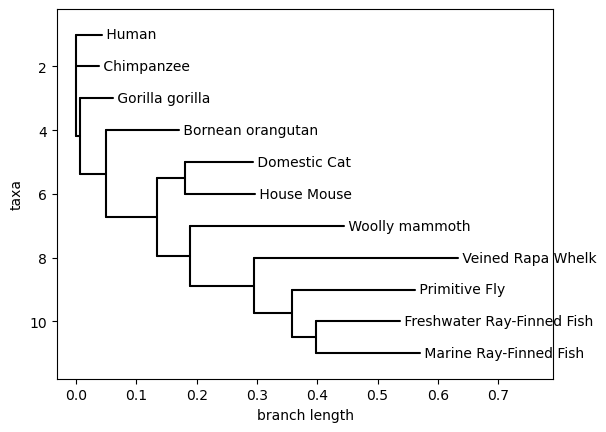

In [46]:
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor

calculator = DistanceCalculator('identity')
constructor = DistanceTreeConstructor(calculator, 'nj')
tree = constructor.build_tree(alignment)
print(tree)

from Bio import Phylo
tree.ladderize()
Phylo.draw(tree, label_func=lambda rec: rec.name if rec.is_terminal() else None)